# Overview
The goal of this study is to evaluate and compare different clustering algorithms.
it consists of 4 key parts:
1. Loading datasets
2. Clustering with each clustering algorithm
3. Measuring performance
4. Summary


In [157]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [158]:
import numpy as np
import matplotlib.pyplot as plt
import clustbench
import genieclust 
import pandas as pd


# Loading datasets

In [159]:
from utils.loader import load_datasets
from utils.preprocess import preprocess_datasets
datasets = load_datasets()
# removing noise
preprocessed_datasets = preprocess_datasets(datasets)


Loading datasets from graves: 100%|██████████| 10/10 [00:00<00:00, 408.43it/s]


# Performing clustering

In [160]:
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from genieclust import Genie
from functools import partial

model_configs = [
    ("KMeans", KMeans),
    ("Genie_g0.1", partial(Genie, 
                    gini_threshold=0.1)),
    ("Genie_g0.3", partial(Genie, 
                    gini_threshold=0.3)),
    ("Genie_g0.5", partial(Genie, 
                    gini_threshold=0.5)),
    ("Genie_g0.7", partial(Genie, gini_threshold=0.7)),
    ("Genie_g0.9", partial(Genie, gini_threshold=0.9)),
    ("AHC_ward", partial(AgglomerativeClustering, 
                    linkage='ward')),
    ("AHC_single", partial(AgglomerativeClustering,
                     linkage='single')),
    ("AHC_average", partial(AgglomerativeClustering, 
                    linkage='average')),
    ("AHC_complete", partial(AgglomerativeClustering, 
                    linkage='complete')),
    ("SpectralClustering", partial(SpectralClustering, 
                            eigen_solver='arpack', 
                            affinity='nearest_neighbors', 
                            n_init=1,
                            random_state=42)),
    ("GaussianMixture", GaussianMixture)
]

In [161]:
from utils.clustering import  cluster_datasets_
import time
results = {}
times={}
for model_name, model in model_configs:
    start_time = time.time()
    results[f'{model_name}'] = cluster_datasets_(preprocessed_datasets, model, model_name)
    end_time = time.time()
    times[f'{model_name}'] = end_time - start_time

Clustering datasets with SpectralClustering:   0%|          | 0/43 [00:00<?, ?it/s]/Users/Jacek/PythonProjects/DEV/Clustering_Comparison/.venv/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
Clustering datasets with SpectralClustering:   2%|▏         | 1/43 [00:00<00:04,  9.16it/s]/Users/Jacek/PythonProjects/DEV/Clustering_Comparison/.venv/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
Clustering datasets with SpectralClustering:   5%|▍         | 2/43 [00:00<00:12,  3.19it/s]/Users/Jacek/PythonProjects/DEV/Clustering_Comparison/.venv/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
Clustering dataset

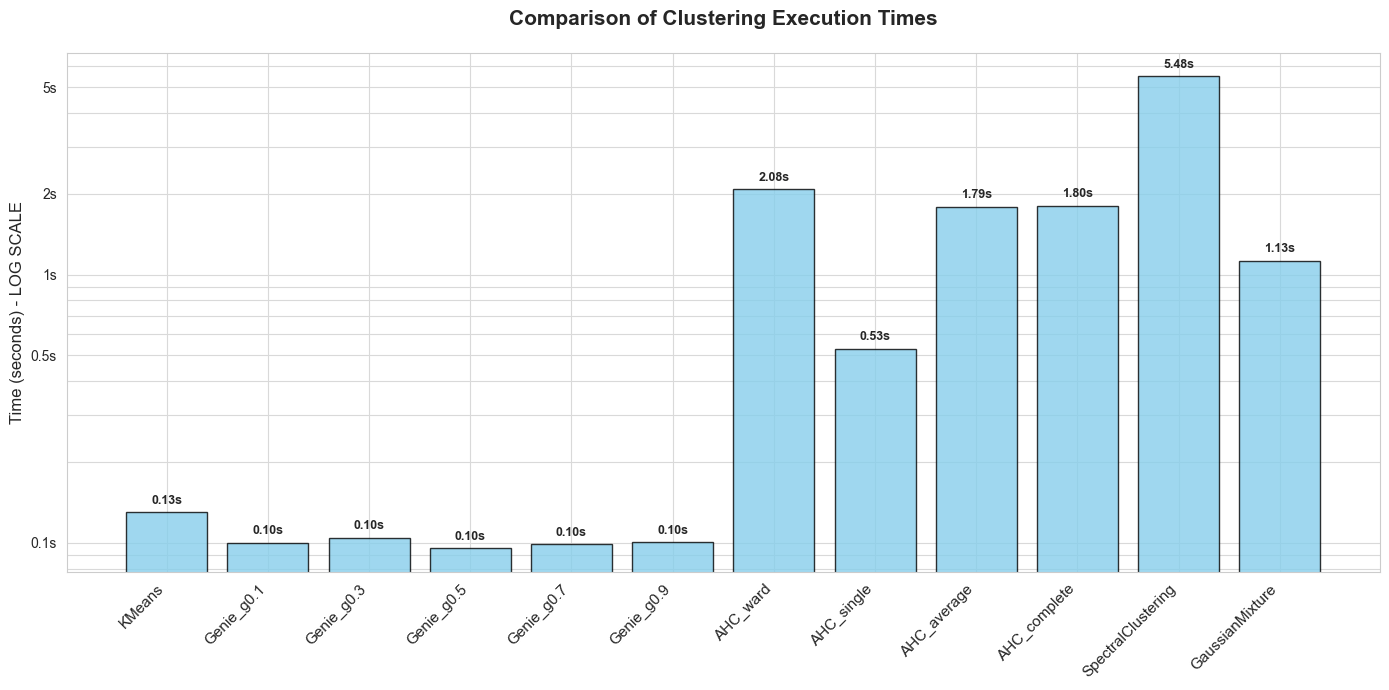

In [ ]:
names = list(times.keys())
values = list(times.values())

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid") 

bars = plt.bar(names, values, color='skyblue', edgecolor='black', alpha=0.8)

plt.yscale('log')


plt.grid(True, which="both", ls="-", color='0.85') 


from matplotlib.ticker import ScalarFormatter
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.yticks([0.1, 0.5, 1, 2, 5], ['0.1s', '0.5s', '1s', '2s', '5s']) 


plt.xticks(rotation=45, ha='right', fontsize=11)
plt.ylabel('Time (seconds) - LOG SCALE', fontsize=12)
plt.title('Comparison of Clustering Execution Times', fontsize=15, fontweight='bold', pad=20)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval * 1.05, f'{yval:.2f}s', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


Widać, ze K-Means i Genie są najszybsze


# Evaluating Created Clusters

In [188]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from genieclust.cluster_validity import calinski_harabasz_index, negated_davies_bouldin_index, silhouette_index
from genieclust.compare_partitions import compare_partitions
import tqdm

def evaluate_clustering(X, y_true, y_pred, nca = True):
    metrics = {
        'ARI': adjusted_rand_score(y_true, y_pred),
        'NMI': normalized_mutual_info_score(y_true, y_pred),
        'NCA' : compare_partitions( y_true, y_pred)['nca'] if nca else None,
        'Silhouette': silhouette_index(X, y_pred),
        'Calinski-Harabasz': calinski_harabasz_index(X, y_pred),
        'Generalised Dunn': negated_davies_bouldin_index(X, y_pred)
    }
    return metrics

scores = {}
for model_name in results.keys():
    model_scores = []
    for dataset_name in tqdm.tqdm(results[model_name].keys(), desc=f"Evaluating {model_name}"):
        Y_pred = results[model_name][dataset_name]['Y_pred']
        Y_true = preprocessed_datasets[dataset_name]['labels']
        X = preprocessed_datasets[dataset_name]['X']
        metrics = evaluate_clustering(X, Y_true, Y_pred)
        model_scores.append({'dataset': dataset_name, **metrics})
    scores[model_name] = pd.DataFrame(model_scores)


        

Evaluating GaussianMixture: 100%|██████████| 43/43 [00:00<00:00, 48.03it/s]


In [164]:
import os
for file in os.listdir('results'):
    os.remove(f'results/{file}')
for model_name, score_df in scores.items():
    
    score_df.to_csv(f'results/{model_name}.csv')

## DBSCAN


Due to its nature DBSCAN will be considered separately 


In [176]:
from utils.eval_dbscan import run_dbscan_evaluation
dbscan_results = {}
dbscan_scores = {}
for dataset_name, dataset_obj in tqdm.tqdm(datasets.items()):
    evaled = run_dbscan_evaluation(dataset_name, dataset_obj)
    if evaled is not None:
        dbscan_results[dataset_name] = evaled
        dbscan_scores[dataset_name] = evaluate_clustering(evaled['X'], evaled['y_true'], evaled['y_dbscan'], nca=False)
    
        


 26%|██▌       | 11/43 [00:00<00:01, 29.84it/s]

Dataset ('sipu', 'flame'): skipped DBSCAN found only 1 cluster


 58%|█████▊    | 25/43 [00:00<00:00, 33.83it/s]

Dataset ('uci', 'glass'): skipped DBSCAN found only 1 cluster
Dataset ('uci', 'ionosphere'): skipped DBSCAN found only 1 cluster


100%|██████████| 43/43 [00:01<00:00, 40.88it/s]


for 3 of our datasets it has skipped 

# SUMMARY

In [216]:
import jinja2


summary_data = []

for algo_name, df in scores.items():
    metrics_cols = ['ARI', 'NMI', 'NCA', 'Silhouette', 'Calinski-Harabasz', 'Generalised Dunn']
    
    stats = df[metrics_cols].agg(['mean', 'median', 'std','min','max']).stack()
    
    stats_dict = {f"{metric}_{stat}": stats[stat, metric] for stat, metric in stats.index}
    stats_dict['Algorithm'] = algo_name
    summary_data.append(stats_dict)

df_summary = pd.DataFrame(summary_data).set_index('Algorithm')
df_summary = df_summary.sort_values(by='ARI_mean', ascending=False)

print("Zbiorcze podsumowanie algorytmów (Mean, Median, Std):")
display(df_summary.style.format("{:.2f}").highlight_max(color='lightgreen', axis=0))

Zbiorcze podsumowanie algorytmów (Mean, Median, Std):


/Users/Jacek/PythonProjects/DEV/Clustering_Comparison/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/Jacek/PythonProjects/DEV/Clustering_Comparison/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/Jacek/PythonProjects/DEV/Clustering_Comparison/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/Jacek/PythonProjects/DEV/Clustering_Comparison/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/Jacek/PythonProjects/DEV/Clustering_Comparison/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: inv

,ARI_mean,NMI_mean,NCA_mean,Silhouette_mean,Calinski-Harabasz_mean,Generalised Dunn_mean,ARI_median,NMI_median,NCA_median,Silhouette_median,Calinski-Harabasz_median,Generalised Dunn_median,ARI_std,NMI_std,NCA_std,Silhouette_std,Calinski-Harabasz_std,Generalised Dunn_std,ARI_min,NMI_min,NCA_min,Silhouette_min,Calinski-Harabasz_min,Generalised Dunn_min,ARI_max,NMI_max,NCA_max,Silhouette_max,Calinski-Harabasz_max,Generalised Dunn_max
Algorithm,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Genie_g0.3,0.75,0.80,0.80,0.38,3369.66,-21.32,0.92,0.95,0.94,0.40,467.36,-0.90,0.30,0.26,0.26,0.20,6303.08,103.92,-0.00,0.00,0.00,0.00,0.00,-660.86,1.00,1.00,1.00,0.75,22439.49,-0.32
Genie_g0.5,0.74,0.80,0.77,0.37,2622.04,-21.31,0.82,0.93,0.84,0.40,418.39,-0.88,0.31,0.27,0.28,0.19,5285.92,103.93,-0.04,0.07,0.15,0.00,0.00,-660.86,1.00,1.00,1.00,0.71,22435.49,-0.36
Genie_g0.1,0.70,0.75,0.77,0.38,3555.34,-21.33,0.92,0.93,0.95,0.40,467.36,-0.95,0.35,0.30,0.28,0.21,6602.60,103.92,-0.00,0.00,0.00,0.00,0.00,-660.86,1.00,1.00,1.00,0.75,24104.93,-0.32
SpectralClustering,0.69,0.75,0.78,0.37,2936.45,-21.29,0.73,0.86,0.83,0.40,384.44,-0.98,0.32,0.28,0.25,0.19,5790.02,103.93,-0.03,0.00,0.02,-0.07,0.00,-660.86,1.00,1.00,1.00,0.68,24478.57,-0.39
Genie_g0.7,0.62,0.72,0.65,0.29,6015.90,-inf,0.61,0.86,0.63,0.29,275.23,-1.04,0.36,0.32,0.33,0.23,33577.22,nan,0.00,0.03,0.03,-0.16,0.00,-inf,1.00,1.00,1.00,0.86,220804.04,-0.29
GaussianMixture,0.61,0.66,0.71,0.45,8127.80,-0.93,0.65,0.66,0.76,0.45,484.41,-0.75,0.35,0.32,0.28,0.18,33787.72,0.60,-0.01,0.00,0.03,-0.02,28.05,-3.01,1.00,1.00,1.00,0.86,221461.07,-0.29
KMeans,0.53,0.59,0.67,0.50,8283.04,-0.79,0.52,0.62,0.71,0.51,629.35,-0.68,0.34,0.32,0.27,0.15,33749.20,0.34,-0.01,0.00,0.01,0.17,59.65,-1.80,1.00,1.00,1.00,0.86,221461.07,-0.29
DBSCAN,0.52,0.61,nan,0.29,2144.56,-0.76,0.59,0.62,nan,0.37,424.17,-0.65,0.35,0.32,nan,0.31,5609.72,0.49,-0.01,0.00,nan,-0.52,3.71,-3.31,1.00,1.00,nan,0.77,32026.21,-0.30
AHC_ward,0.52,0.59,0.66,0.49,8280.73,-0.79,0.55,0.57,0.68,0.49,552.85,-0.74,0.35,0.31,0.27,0.15,33685.90,0.33,-0.10,0.00,0.04,0.14,54.05,-1.67,1.00,1.00,1.00,0.86,220804.04,-0.29


In [215]:
import pandas as pd

metrics = ['ARI', 'NMI', 'NCA', 'Silhouette', 'Calinski-Harabasz']

valid_datasets = scores['DBSCAN'].index.unique()

all_results = []
for algo_name, df in scores.items():
    df_filtered = df[df.index.isin(valid_datasets)].copy()
    df_filtered['Algorithm'] = algo_name
    all_results.append(df_filtered)

df_all = pd.concat(all_results)

for m in metrics:
    if m in df_all.columns:
        df_all[f'rank_{m}'] = df_all.groupby(level=0)[m].rank(ascending=False, method='min')

rank_cols = [c for c in df_all.columns if c.startswith('rank_')]
df_ranks = df_all.groupby('Algorithm')[rank_cols].mean()
df_ranks['Average_Rank'] = df_ranks.mean(axis=1)
df_ranks = df_ranks.sort_values('Average_Rank')

display(df_ranks.style.format("{:.2f}").background_gradient(cmap='RdYlGn_r'), )


,rank_ARI,rank_NMI,rank_NCA,rank_Silhouette,rank_Calinski-Harabasz,Average_Rank
Algorithm,,,,,,
Genie_g0.1,4.28,4.28,3.70,6.15,5.22,4.72
KMeans,6.62,6.55,6.05,2.70,1.95,4.78
Genie_g0.3,3.90,3.77,3.90,6.70,5.95,4.84
SpectralClustering,4.67,4.53,3.73,5.92,5.90,4.95
GaussianMixture,5.47,5.65,5.17,5.03,4.62,5.19
Genie_g0.5,4.15,4.00,4.33,6.85,6.95,5.26
AHC_ward,7.08,7.65,6.33,4.67,3.77,5.90
AHC_average,7.05,7.42,6.67,3.95,5.03,6.03
Genie_g0.7,5.83,5.80,5.90,7.80,8.35,6.73


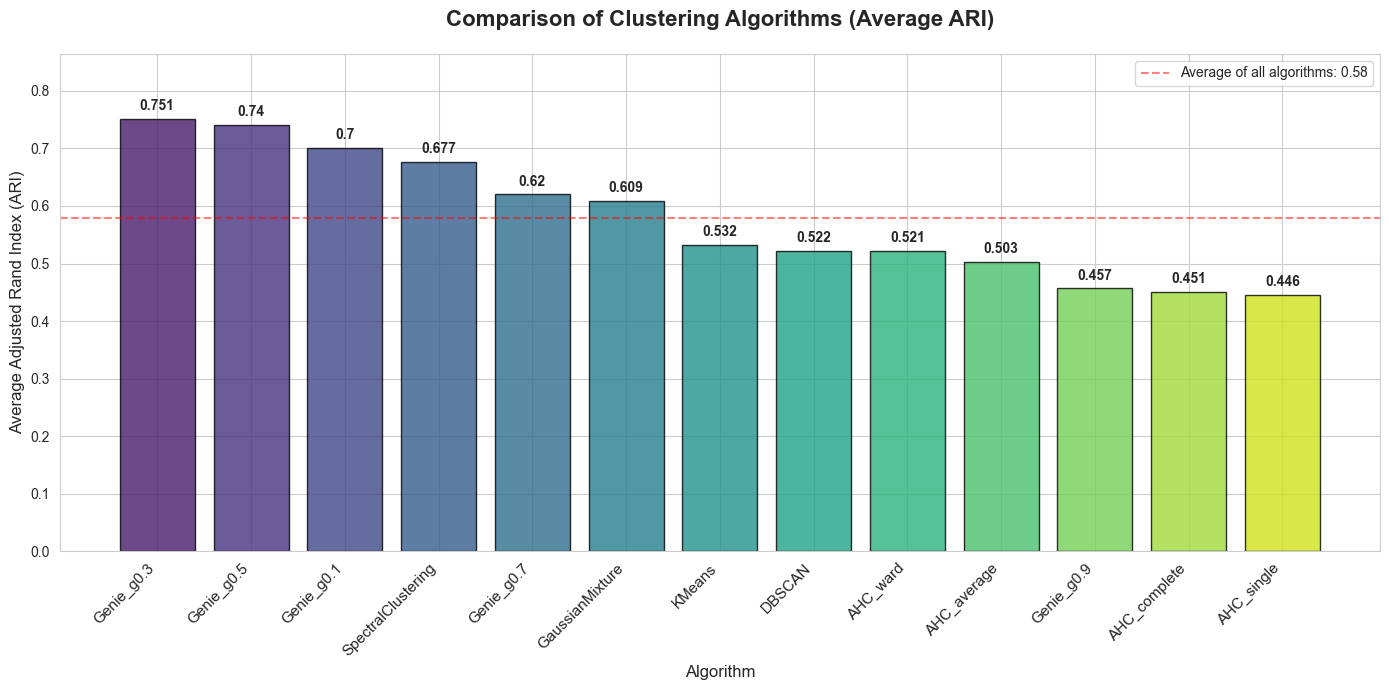

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")


df_plot = df_summary.sort_values('ARI_mean', ascending=False)


colors = sns.color_palette("viridis", len(df_plot))
bars = plt.bar(df_plot.index, df_plot['ARI_mean'], color=colors, edgecolor='black', alpha=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3), 
             ha='center', va='bottom', fontweight='bold', fontsize=10)


plt.title('Comparison of Clustering Algorithms (Average ARI)', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Average Adjusted Rand Index (ARI)', fontsize=12)
plt.xlabel('Algorithm', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.ylim(0, max(df_plot['ARI_mean']) * 1.15) 


plt.axhline(df_plot['ARI_mean'].mean(), color='red', linestyle='--', alpha=0.5, label=f'Average of all algorithms: {df_plot["ARI_mean"].mean():.2f}')
plt.legend()

plt.tight_layout()
plt.show()

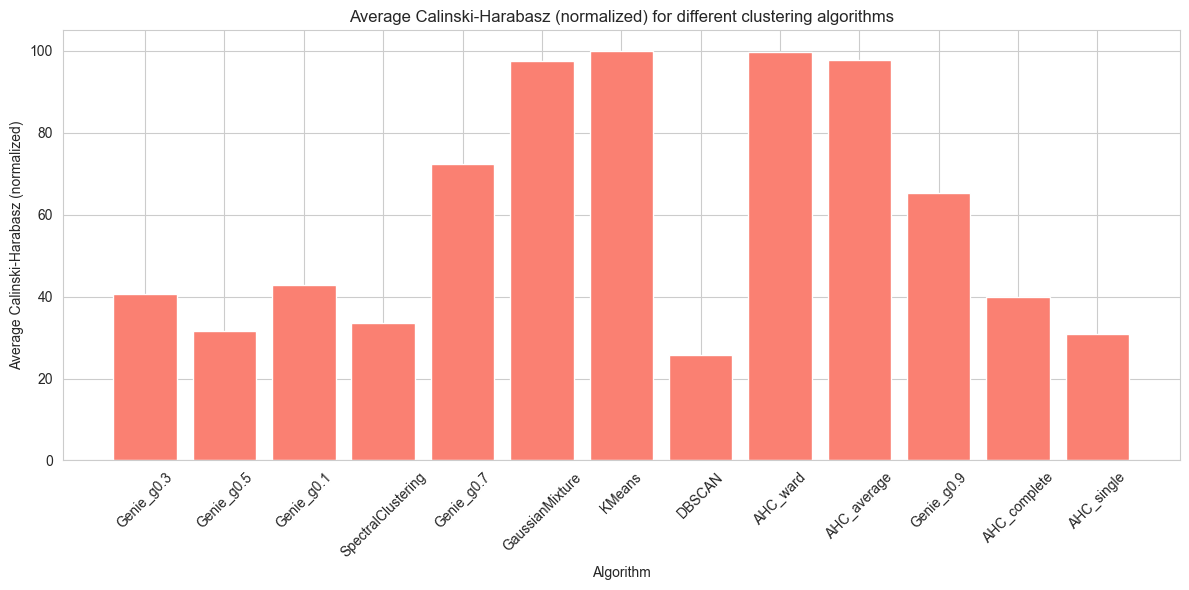

In [129]:
df_summary['Calinski-Harabasz_mean'] = df_summary['Calinski-Harabasz_mean'] / df_summary['Calinski-Harabasz_mean'].max() * 100
plt.figure(figsize=(12, 6))
plt.bar(df_summary.index, df_summary['Calinski-Harabasz_mean'], color='salmon')
plt.title('Average Calinski-Harabasz (normalized) for different clustering algorithms')
plt.xlabel('Algorithm')
plt.ylabel('Average Calinski-Harabasz (normalized)')
plt.xticks(rotation=45)
plt.tight_layout()  

Calinski-Harabasz for Genie (g=0.3): 5.80
Calinski-Harabasz for KMeans: 237.45
Normalized Mutual Information for Genie (g=0.3): 1.00
Normalized Mutual Information for KMeans: 0.00


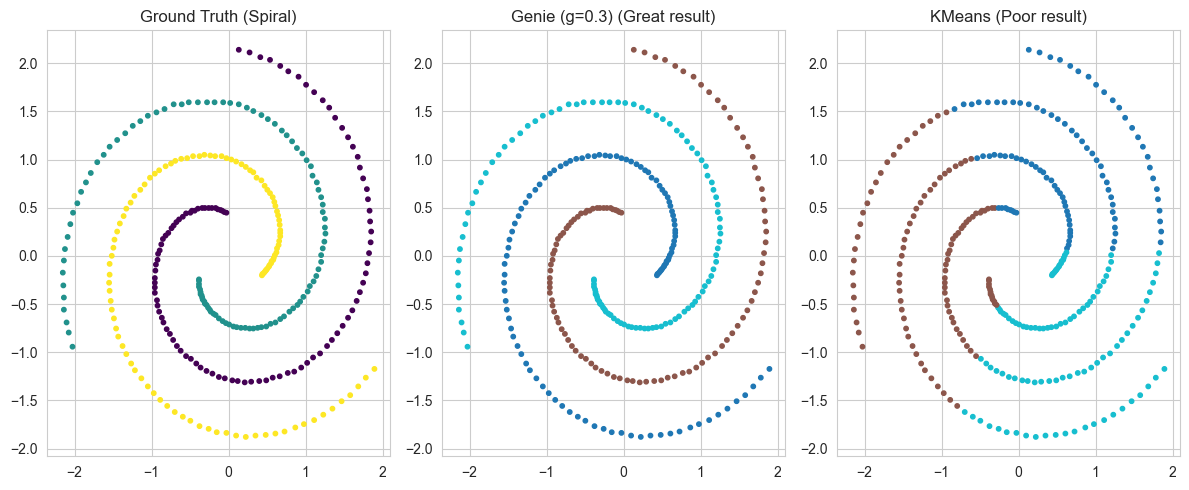

In [211]:
import matplotlib.pyplot as plt

def plot_comparison(dataset_name, dataset_obj, algo1_name, algo2_name):
    X = dataset_obj.data
    y_true = dataset_obj.labels[0]

    
    m1 = genieclust.Genie(n_clusters=len(np.unique(y_true[y_true!=0])), gini_threshold=0.3)
    y1 = m1.fit_predict(X)
    
    m2 = KMeans(n_clusters=len(np.unique(y_true[y_true!=0])))
    y2 = m2.fit_predict(X)
    nm1 = normalized_mutual_info_score(y_true, y1)
    nm2 = normalized_mutual_info_score(y_true, y2)
    calinski_harabasz_1 = calinski_harabasz_index(X, y1)
    calinski_harabasz_2 = calinski_harabasz_index(X, y2)
    print(f"Calinski-Harabasz for {algo1_name}: {calinski_harabasz_1:.2f}")
    print(f"Calinski-Harabasz for {algo2_name}: {calinski_harabasz_2:.2f}")
    print(f"Normalized Mutual Information for {algo1_name}: {nm1:.2f}")
    print(f"Normalized Mutual Information for {algo2_name}: {nm2:.2f}")
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
    
    ax1.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=10)
    ax1.set_title(f"Ground Truth ({dataset_name})")
    
    ax2.scatter(X[:, 0], X[:, 1], c=y1, cmap='tab10', s=10)
    ax2.set_title(f"{algo1_name} (Great result)")
    
    ax3.scatter(X[:, 0], X[:, 1], c=y2, cmap='tab10', s=10)
    ax3.set_title(f"{algo2_name} (Poor result)")
    
    plt.tight_layout()
    plt.show()


plot_comparison('Spiral', datasets[('sipu', 'spiral')], 'Genie (g=0.3)', 'KMeans')


Calinski-Harabasz for Genie: 554.95
Calinski-Harabasz for KMeans: 1396.42
Silhouette for Genie: 554.95
Normalized Mutual Information for Genie: 0.71
Normalized Mutual Information for KMeans: 0.88


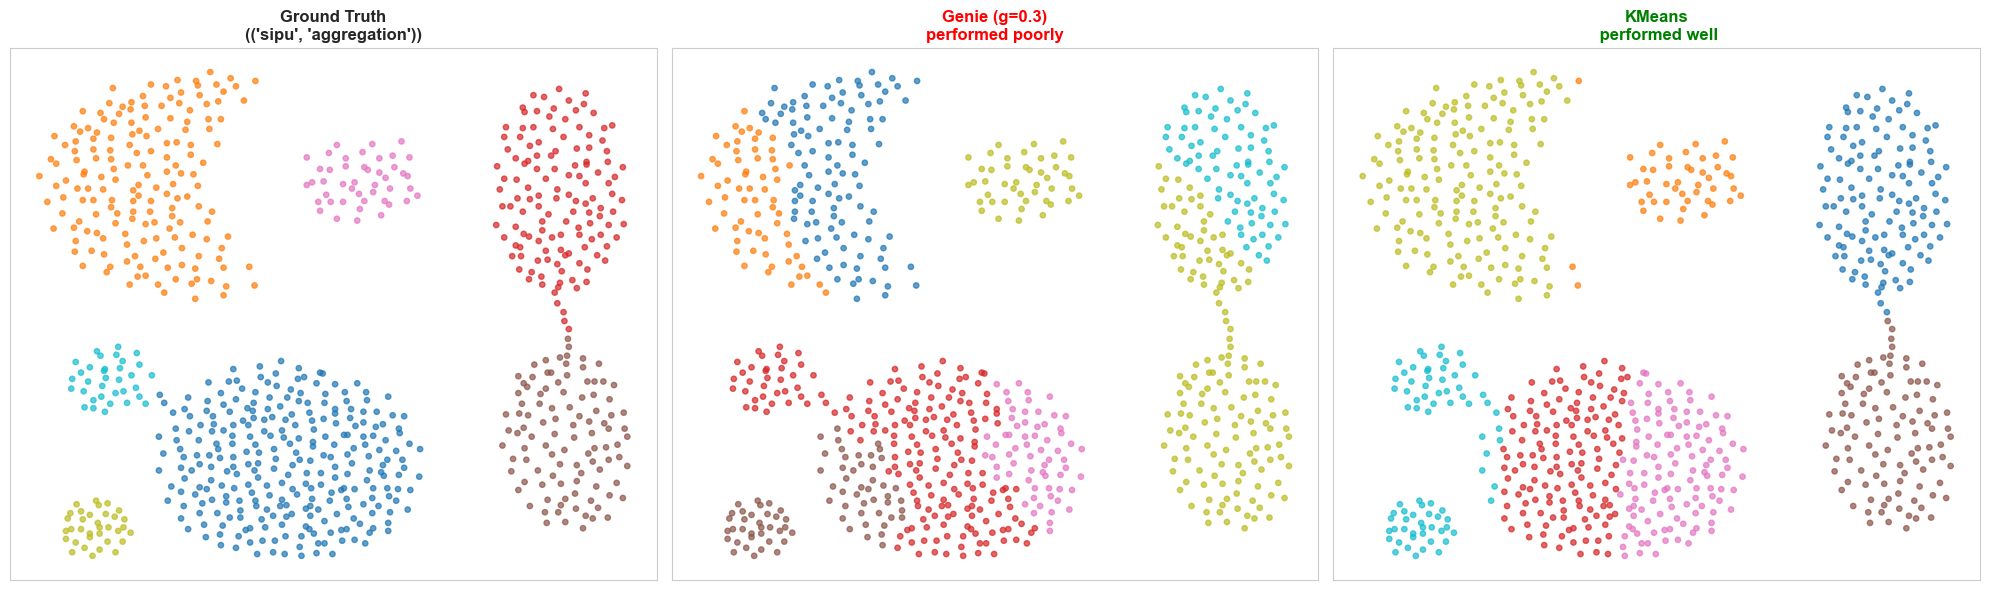

In [212]:
dataset_name = ('sipu', 'aggregation')
data_obj = datasets[dataset_name]
X = data_obj.data
y_true = data_obj.labels[0]
n_clust = len(np.unique(y_true[y_true != -1]))

# Wynik Genie (Lider)
m1 = genieclust.Genie(n_clusters=n_clust, gini_threshold=0.3)
y1 = m1.fit_predict(X)

# Wynik KMeans (Słabszy wynik przy nieregularnych kształtach)
m2 = KMeans(n_clusters=n_clust, n_init=10)
y2 = m2.fit_predict(X)
silh = calinski_harabasz_index(X, y1)
calinski_harabasz_1 = calinski_harabasz_index(X, y1)
calinski_harabasz_2 = calinski_harabasz_index(X, y2)
nm1 = normalized_mutual_info_score(y_true, y1)
nm2 = normalized_mutual_info_score(y_true, y2)
print(f"Calinski-Harabasz for {'Genie'}: {calinski_harabasz_1:.2f}")
print(f"Calinski-Harabasz for {'KMeans'}: {calinski_harabasz_2:.2f}")
print(f"Silhouette for {'Genie'}: {silh:.2f}")
print(f"Normalized Mutual Information for {'Genie'}: {nm1:.2f}")
print(f"Normalized Mutual Information for {'KMeans'}: {nm2:.2f}")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Ground Truth
ax1.scatter(X[:, 0], X[:, 1], c=y_true, cmap='tab10', s=15, alpha=0.7)
ax1.set_title(f"Ground Truth\n({dataset_name})", fontweight='bold')

# Genie
ax2.scatter(X[:, 0], X[:, 1], c=y1, cmap='tab10', s=15, alpha=0.7)
ax2.set_title(f"Genie (g=0.3)\nperformed poorly", fontweight='bold', color='red')

# KMeans
ax3.scatter(X[:, 0], X[:, 1], c=y2, cmap='tab10', s=15, alpha=0.7)
ax3.set_title(f"KMeans\n performed well", fontweight='bold', color='green')

for ax in [ax1, ax2, ax3]:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()